In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style for better visualizations
plt.style.use('seaborn')
sns.set_palette('husl')

# Display all columns
pd.set_option('display.max_columns', None)


In [2]:
# Load the dataset
df = pd.read_csv('../../data/benin_solar.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (525600, 19)


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-08-09 00:01,-1.2,-0.2,-1.1,0.0,0.0,26.2,93.4,0.0,0.4,0.1,122.1,0.0,998,0,0.0,26.3,26.2,NaN
1,2021-08-09 00:02,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.6,0.0,0.0,0.0,0.0,0.0,998,0,0.0,26.3,26.2,NaN
2,2021-08-09 00:03,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.7,0.3,1.1,0.5,124.6,1.5,997,0,0.0,26.4,26.2,NaN
3,2021-08-09 00:04,-1.1,-0.1,-1.0,0.0,0.0,26.2,93.3,0.2,0.7,0.4,120.3,1.3,997,0,0.0,26.4,26.3,NaN
4,2021-08-09 00:05,-1.0,-0.1,-1.0,0.0,0.0,26.2,93.3,0.1,0.7,0.3,113.2,1.0,997,0,0.0,26.4,26.3,NaN


In [3]:

# Set style for better visualizations
plt.style.use('default')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = [12, 8]

In [4]:
# Display all columns
pd.set_option('display.max_columns', None)

In [5]:
# Load the dataset
df = pd.read_csv('../../data/benin_solar.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
print(f"Dataset shape: {df.shape}")
print("\nFirst few rows:")
print(df.head())

Dataset shape: (525600, 19)

First few rows:
            Timestamp  GHI  DNI  DHI  ModA  ModB  Tamb    RH   WS  WSgust  \
0 2021-08-09 00:01:00 -1.2 -0.2 -1.1   0.0   0.0  26.2  93.4  0.0     0.4   
1 2021-08-09 00:02:00 -1.1 -0.2 -1.1   0.0   0.0  26.2  93.6  0.0     0.0   
2 2021-08-09 00:03:00 -1.1 -0.2 -1.1   0.0   0.0  26.2  93.7  0.3     1.1   
3 2021-08-09 00:04:00 -1.1 -0.1 -1.0   0.0   0.0  26.2  93.3  0.2     0.7   
4 2021-08-09 00:05:00 -1.0 -0.1 -1.0   0.0   0.0  26.2  93.3  0.1     0.7   

   WSstdev     WD  WDstdev   BP  Cleaning  Precipitation  TModA  TModB  \
0      0.1  122.1      0.0  998         0            0.0   26.3   26.2   
1      0.0    0.0      0.0  998         0            0.0   26.3   26.2   
2      0.5  124.6      1.5  997         0            0.0   26.4   26.2   
3      0.4  120.3      1.3  997         0            0.0   26.4   26.3   
4      0.3  113.2      1.0  997         0            0.0   26.4   26.3   

   Comments  
0       NaN  
1       NaN  
2    

In [6]:
# 1. Summary Statistics & Missing-Value Report
print("\nSummary Statistics:")
numeric_cols = df.select_dtypes(include=[np.number]).columns
print(df[numeric_cols].describe())


Summary Statistics:
                 GHI            DNI            DHI           ModA  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      240.559452     167.187516     115.358961     236.589496   
std       331.131327     261.710501     158.691074     326.894859   
min       -12.900000      -7.800000     -12.600000       0.000000   
25%        -2.000000      -0.500000      -2.100000       0.000000   
50%         1.800000      -0.100000       1.600000       4.500000   
75%       483.400000     314.200000     216.300000     463.700000   
max      1413.000000     952.300000     759.200000    1342.300000   

                ModB           Tamb             RH             WS  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      228.883576      28.179683      54.487969       2.121113   
std       316.536515       5.924297      28.073069       1.603466   
min         0.000000      11.000000       2.100000       0.000000   
25%         

In [7]:
# Missing value analysis
missing_values = df.isna().sum()
missing_percentages = (missing_values / len(df)) * 100

In [8]:
print("\nColumns with >5% missing values:")
print(missing_percentages[missing_percentages > 5].sort_values(ascending=False))


Columns with >5% missing values:
Comments    100.0
dtype: float64


In [9]:
# 2. Outlier Detection & Basic Cleaning
def flag_outliers(df, column):
    z_scores = stats.zscore(df[column].dropna())
    return np.abs(z_scores) > 3

In [10]:
# Columns to check for outliers
outlier_columns = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']


In [11]:
# Create a dictionary to store outlier flags
outliers_dict = {}
for col in outlier_columns:
    if col in df.columns:
        outliers_dict[f'{col}_outlier'] = flag_outliers(df, col)
        print(f"Number of outliers in {col}: {sum(outliers_dict[f'{col}_outlier'])}")

Number of outliers in GHI: 89
Number of outliers in DNI: 0
Number of outliers in DHI: 3738
Number of outliers in ModA: 27
Number of outliers in ModB: 63
Number of outliers in WS: 3109
Number of outliers in WSgust: 3500


In [12]:
# Create clean dataframe
df_clean = df.copy()

In [13]:
# Handle missing values in key columns
for col in outlier_columns:
    if col in df.columns:
        # Impute missing values with median
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
        
        # Replace outliers with median
        mask = outliers_dict[f'{col}_outlier']
        df_clean.loc[mask, col] = df_clean[col].median()

In [14]:
# Export cleaned data
df_clean.to_csv('../../data/benin_clean.csv', index=False)
print("\nCleaned data exported to benin_clean.csv")


Cleaned data exported to benin_clean.csv


In [15]:
# 3. Time Series Analysis
plt.figure(figsize=(15, 12))

<Figure size 1500x1200 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

Text(0.5, 0.98, 'Time Series Analysis')

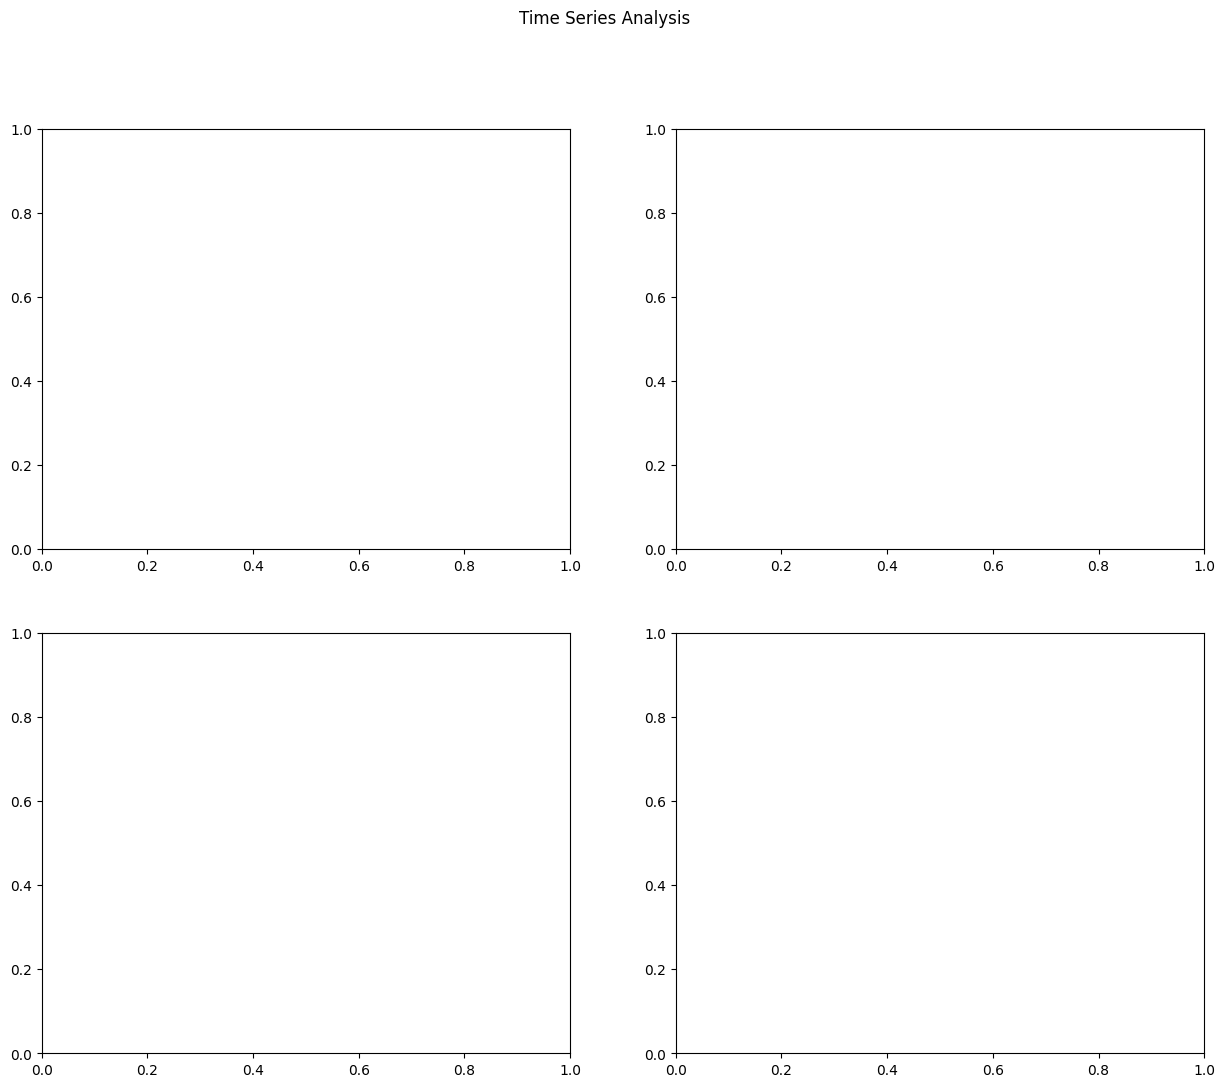

In [16]:
# Create time series plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Time Series Analysis')

In [17]:
# GHI
axes[0, 0].plot(df_clean['Timestamp'], df_clean['GHI'])
axes[0, 0].set_title('GHI over Time')
axes[0, 0].set_xlabel('Time')
axes[0, 0].set_ylabel('GHI')

Text(4.444444444444452, 0.5, 'GHI')

In [18]:
# DNI
axes[0, 1].plot(df_clean['Timestamp'], df_clean['DNI'])
axes[0, 1].set_title('DNI over Time')
axes[0, 1].set_xlabel('Time')
axes[0, 1].set_ylabel('DNI')

Text(638.5353535353535, 0.5, 'DNI')

In [19]:
# DHI
axes[1, 0].plot(df_clean['Timestamp'], df_clean['DHI'])
axes[1, 0].set_title('DHI over Time')
axes[1, 0].set_xlabel('Time')
axes[1, 0].set_ylabel('DHI')

Text(4.444444444444452, 0.5, 'DHI')

In [20]:
# Tamb
axes[1, 1].plot(df_clean['Timestamp'], df_clean['Tamb'])
axes[1, 1].set_title('Ambient Temperature over Time')
axes[1, 1].set_xlabel('Time')
axes[1, 1].set_ylabel('Temperature')

Text(638.5353535353535, 0.5, 'Temperature')

In [21]:
plt.tight_layout()
plt.show()


<Figure size 1200x800 with 0 Axes>

In [22]:
# Monthly patterns
df_clean['Month'] = df_clean['Timestamp'].dt.month
monthly_means = df_clean.groupby('Month')[['GHI', 'DNI', 'DHI', 'Tamb']].mean()

<Figure size 1200x600 with 0 Axes>

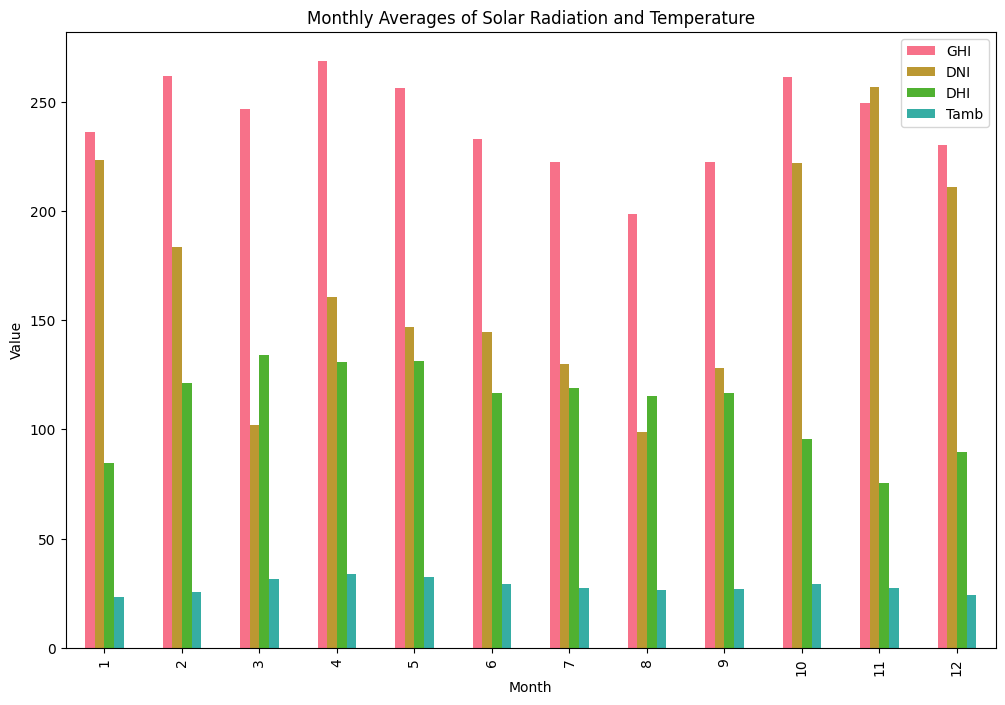

In [23]:
plt.figure(figsize=(12, 6))
monthly_means.plot(kind='bar')
plt.title('Monthly Averages of Solar Radiation and Temperature')
plt.xlabel('Month')
plt.ylabel('Value')
plt.legend()
plt.show()

In [24]:
# 4. Cleaning Impact Analysis
cleaning_impact = df_clean.groupby('Cleaning')[['ModA', 'ModB', 'TModA', 'TModB']].mean()

<Figure size 1000x600 with 0 Axes>

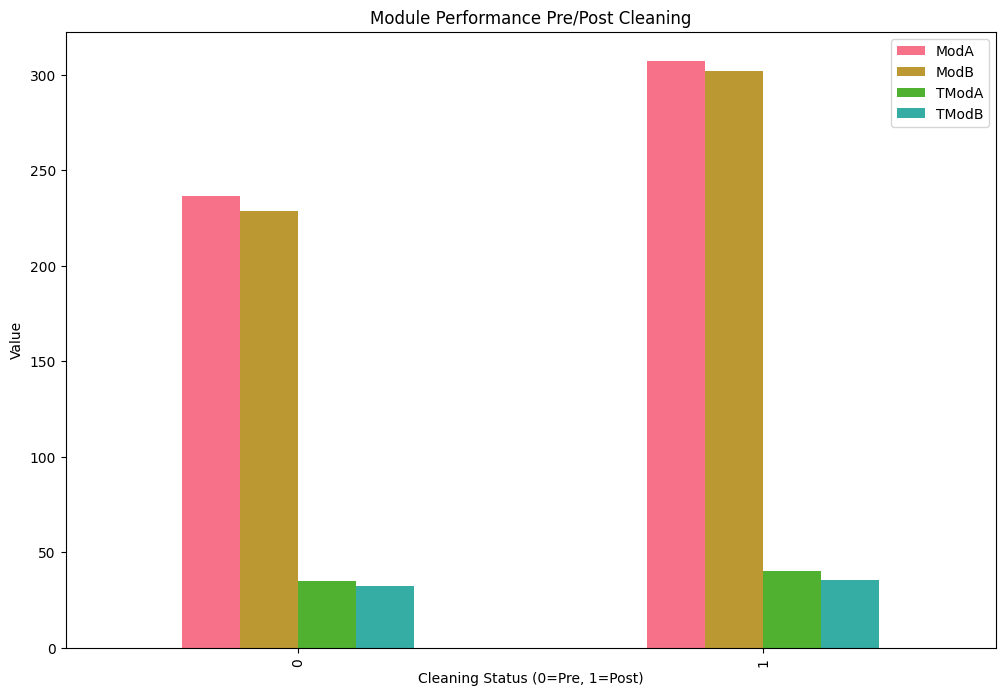

In [25]:
plt.figure(figsize=(10, 6))
cleaning_impact.plot(kind='bar')
plt.title('Module Performance Pre/Post Cleaning')
plt.xlabel('Cleaning Status (0=Pre, 1=Post)')
plt.ylabel('Value')
plt.legend()
plt.show()

In [26]:
# 5. Correlation & Relationship Analysis
corr_columns = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'TModA', 'TModB']
correlation_matrix = df_clean[corr_columns].corr()

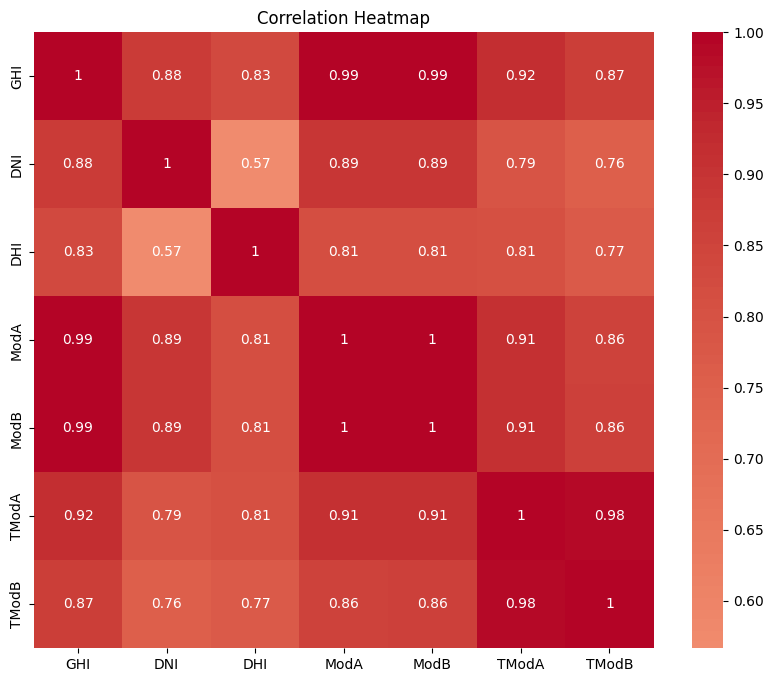

In [27]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

Text(0.5, 0.98, 'Relationship Analysis')

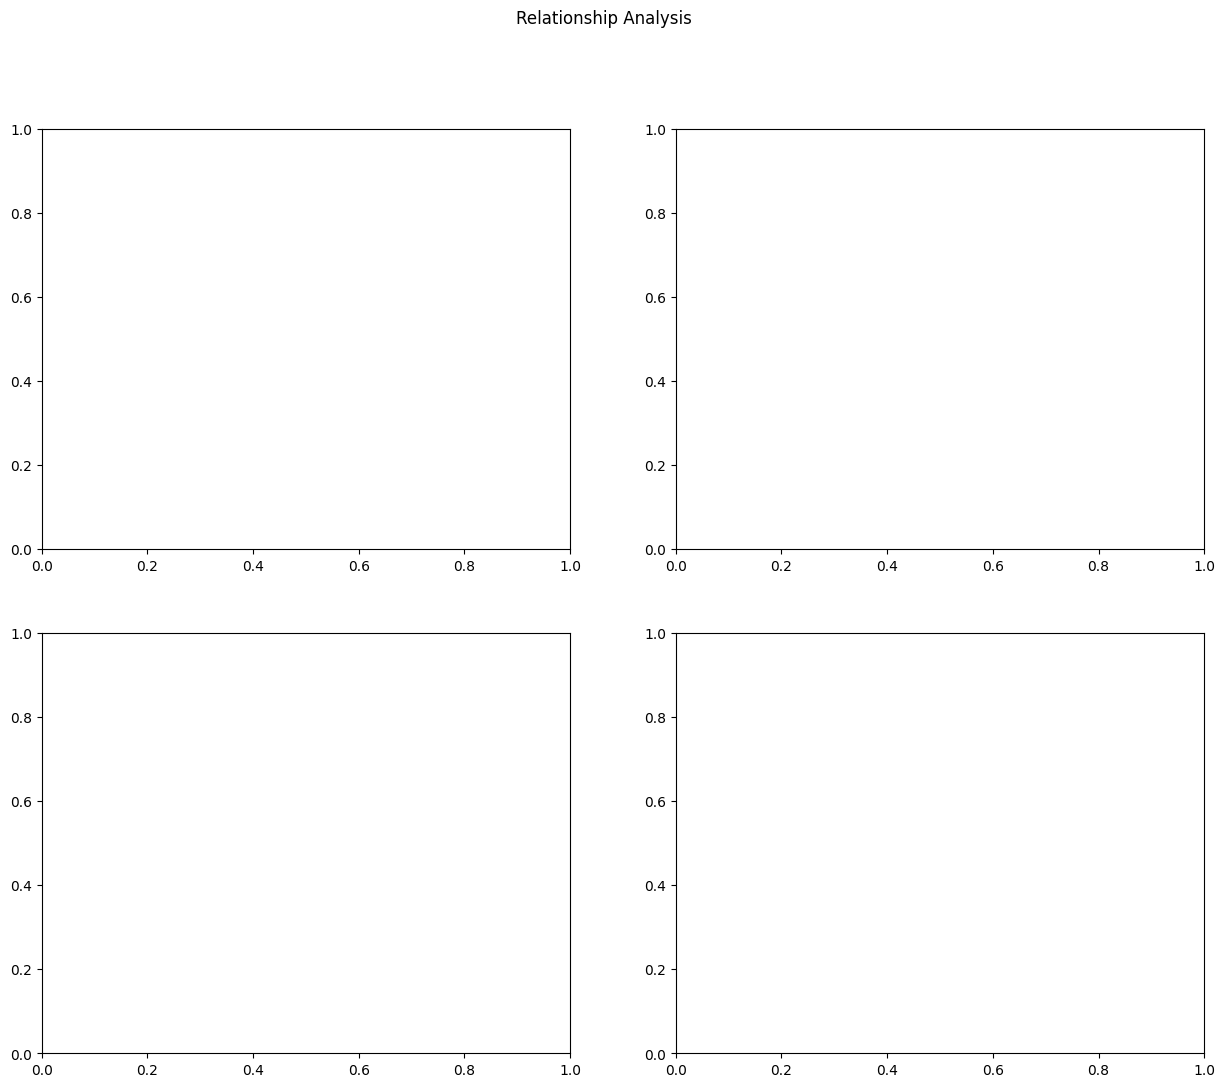

In [28]:
# Scatter plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Relationship Analysis')

In [29]:
# WS vs GHI
sns.scatterplot(data=df_clean, x='WS', y='GHI', ax=axes[0, 0], alpha=0.5)
axes[0, 0].set_title('Wind Speed vs GHI')

# WSgust vs GHI
sns.scatterplot(data=df_clean, x='WSgust', y='GHI', ax=axes[0, 1], alpha=0.5)
axes[0, 1].set_title('Wind Gust vs GHI')

# RH vs Tamb
sns.scatterplot(data=df_clean, x='RH', y='Tamb', ax=axes[1, 0], alpha=0.5)
axes[1, 0].set_title('Relative Humidity vs Temperature')

# RH vs GHI
sns.scatterplot(data=df_clean, x='RH', y='GHI', ax=axes[1, 1], alpha=0.5)
axes[1, 1].set_title('Relative Humidity vs GHI')

plt.tight_layout()
plt.show()


<Figure size 1200x800 with 0 Axes>

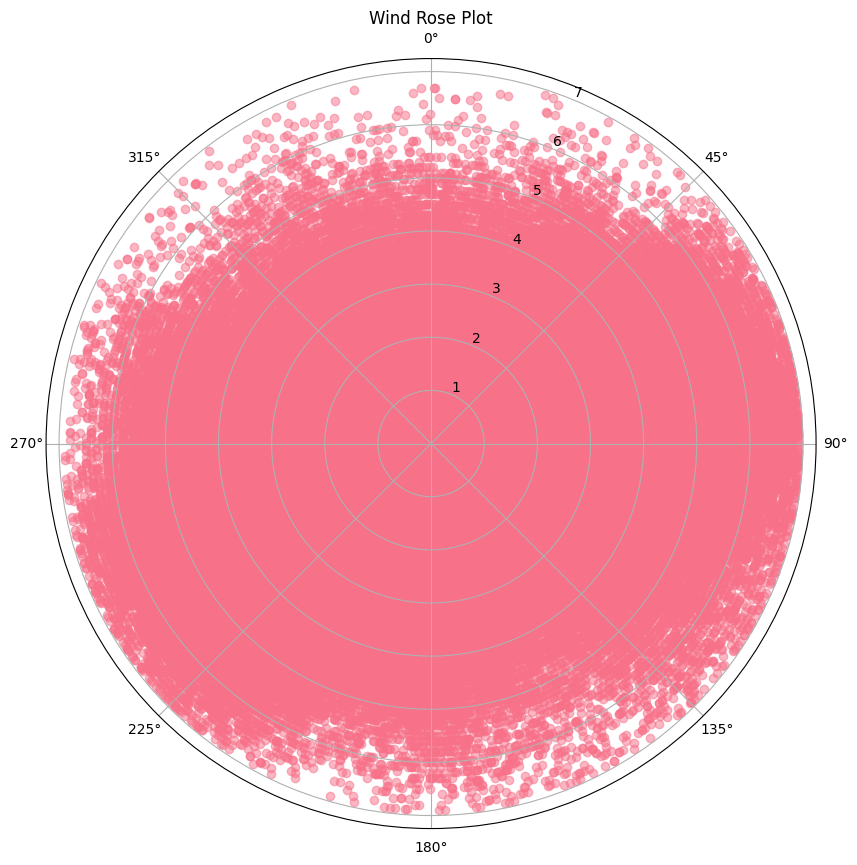

In [30]:
# 6. Wind & Distribution Analysis
# Wind rose plot
plt.figure(figsize=(10, 10))
ax = plt.subplot(111, projection='polar')

# Convert wind direction to radians
wd_rad = np.radians(df_clean['WD'])

# Create scatter plot
ax.scatter(wd_rad, df_clean['WS'], alpha=0.5)
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
plt.title('Wind Rose Plot')
plt.show()

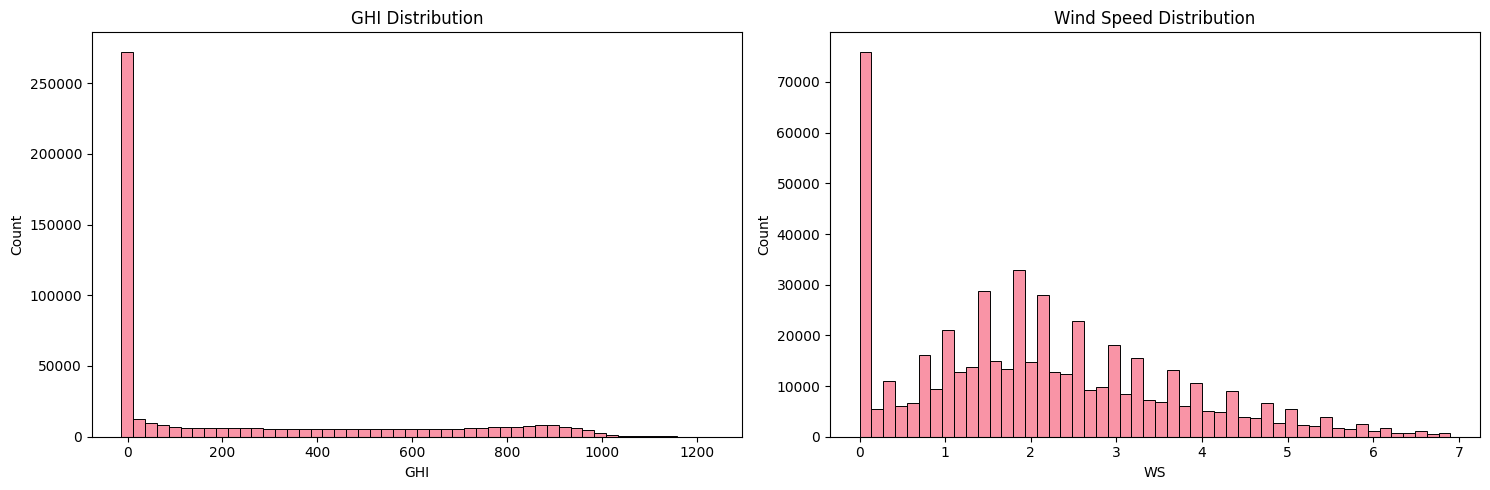

In [31]:
# Distribution analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# GHI distribution
sns.histplot(data=df_clean, x='GHI', bins=50, ax=ax1)
ax1.set_title('GHI Distribution')

# Wind Speed distribution
sns.histplot(data=df_clean, x='WS', bins=50, ax=ax2)
ax2.set_title('Wind Speed Distribution')

plt.tight_layout()
plt.show()

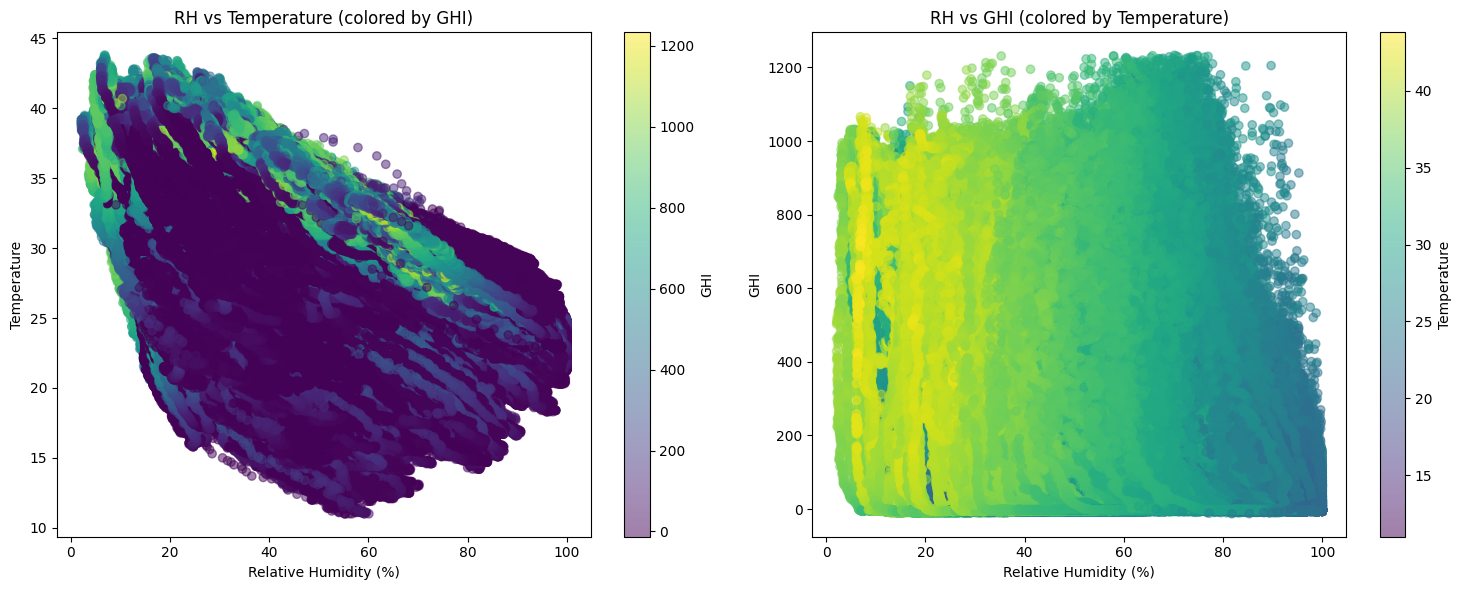

In [32]:
# 7. Temperature Analysis
# Temperature and humidity relationship analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# RH vs Temperature with GHI as color
scatter1 = ax1.scatter(df_clean['RH'], df_clean['Tamb'], c=df_clean['GHI'], cmap='viridis', alpha=0.5)
ax1.set_xlabel('Relative Humidity (%)')
ax1.set_ylabel('Temperature')
ax1.set_title('RH vs Temperature (colored by GHI)')
plt.colorbar(scatter1, ax=ax1, label='GHI')

# RH vs GHI with Temperature as color
scatter2 = ax2.scatter(df_clean['RH'], df_clean['GHI'], c=df_clean['Tamb'], cmap='viridis', alpha=0.5)
ax2.set_xlabel('Relative Humidity (%)')
ax2.set_ylabel('GHI')
ax2.set_title('RH vs GHI (colored by Temperature)')
plt.colorbar(scatter2, ax=ax2, label='Temperature')

plt.tight_layout()
plt.show()

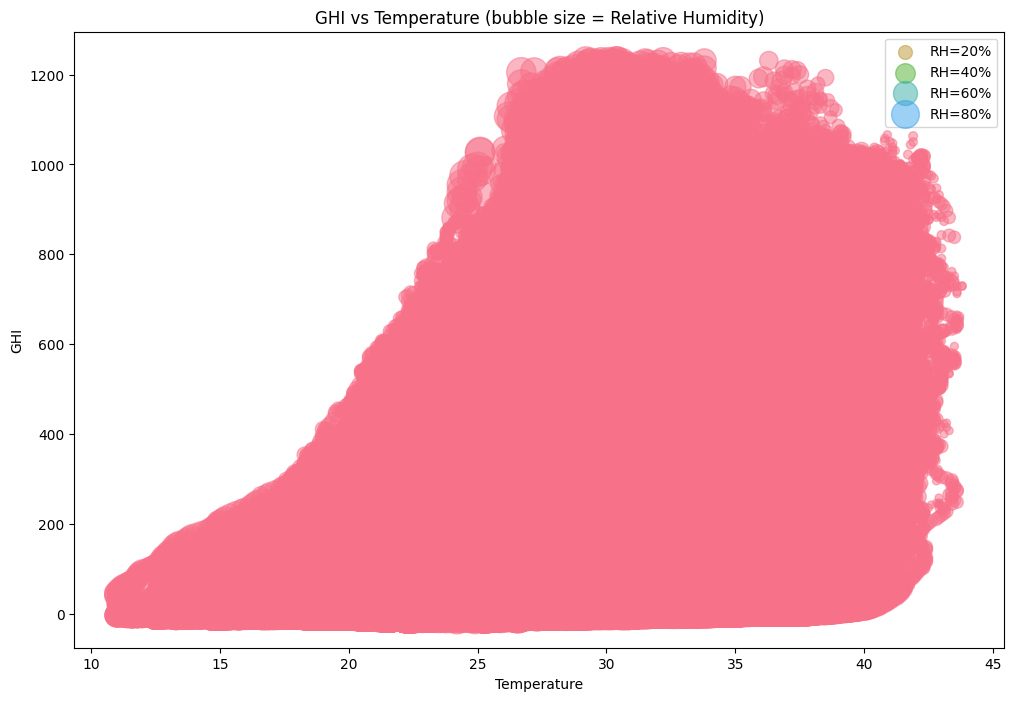

In [33]:
# 8. Bubble Chart Analysis
plt.figure(figsize=(12, 8))

# Create bubble plot
plt.scatter(df_clean['Tamb'], df_clean['GHI'], s=df_clean['RH']*5, alpha=0.5)
plt.xlabel('Temperature')
plt.ylabel('GHI')
plt.title('GHI vs Temperature (bubble size = Relative Humidity)')

# Add a legend for bubble sizes
legend_elements = [plt.scatter([], [], s=size*5, label=f'RH={size}%', alpha=0.5)
                  for size in [20, 40, 60, 80]]
plt.legend(handles=legend_elements)

plt.show() 